<a href="https://colab.research.google.com/github/RafayRizwan023/Deep_Learning_Labs_Raf023/blob/main/Lab_04_Data_Augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:

import os
import matplotlib.pyplot as plt
from torchvision import datasets, transforms  #----------->  Used for importing datasets and Trasfromation on images
from torchvision.transforms import functional
from torchvision.utils import save_image
from torch.autograd import Function

In [24]:
save_folder1 = "/content/Augmented Data frog"
os.makedirs(save_folder1, exist_ok=True)

save_folder2 = "/content/Augmented Data Truck"
os.makedirs(save_folder2, exist_ok=True)

In [25]:

# Used te Pytorch handbook to understand & correctly use Pytorch transformation function
# Based on what trasfomration to apply on the image and to what extent'
# No zoom function in pytorch (as far as i looked)
augment = transforms.Compose([
    transforms.RandomAffine(
        degrees=40,
        shear=20,
        scale=(0.8, 1.2),
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=(0.5, 1.5)),
    transforms.ToTensor(),
])

In [31]:
#using CIFAR 10 Dataset images for this task

dataset = datasets.CIFAR10(root="./data", train=True, download=True)
print("Available classes:", dataset.classes)

# Using the truck and frog images for this task
img_1, label_1 = dataset[1]
img_2, label_2 = dataset[0]

# Saveing the original in the respective folder for comparison
functional.to_pil_image(functional.to_tensor(img_1)).save(os.path.join(save_folder2, "original_1.png"))
functional.to_pil_image(functional.to_tensor(img_2)).save(os.path.join(save_folder1, "original_2.png"))


Available classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
using the truck and frog images for this task


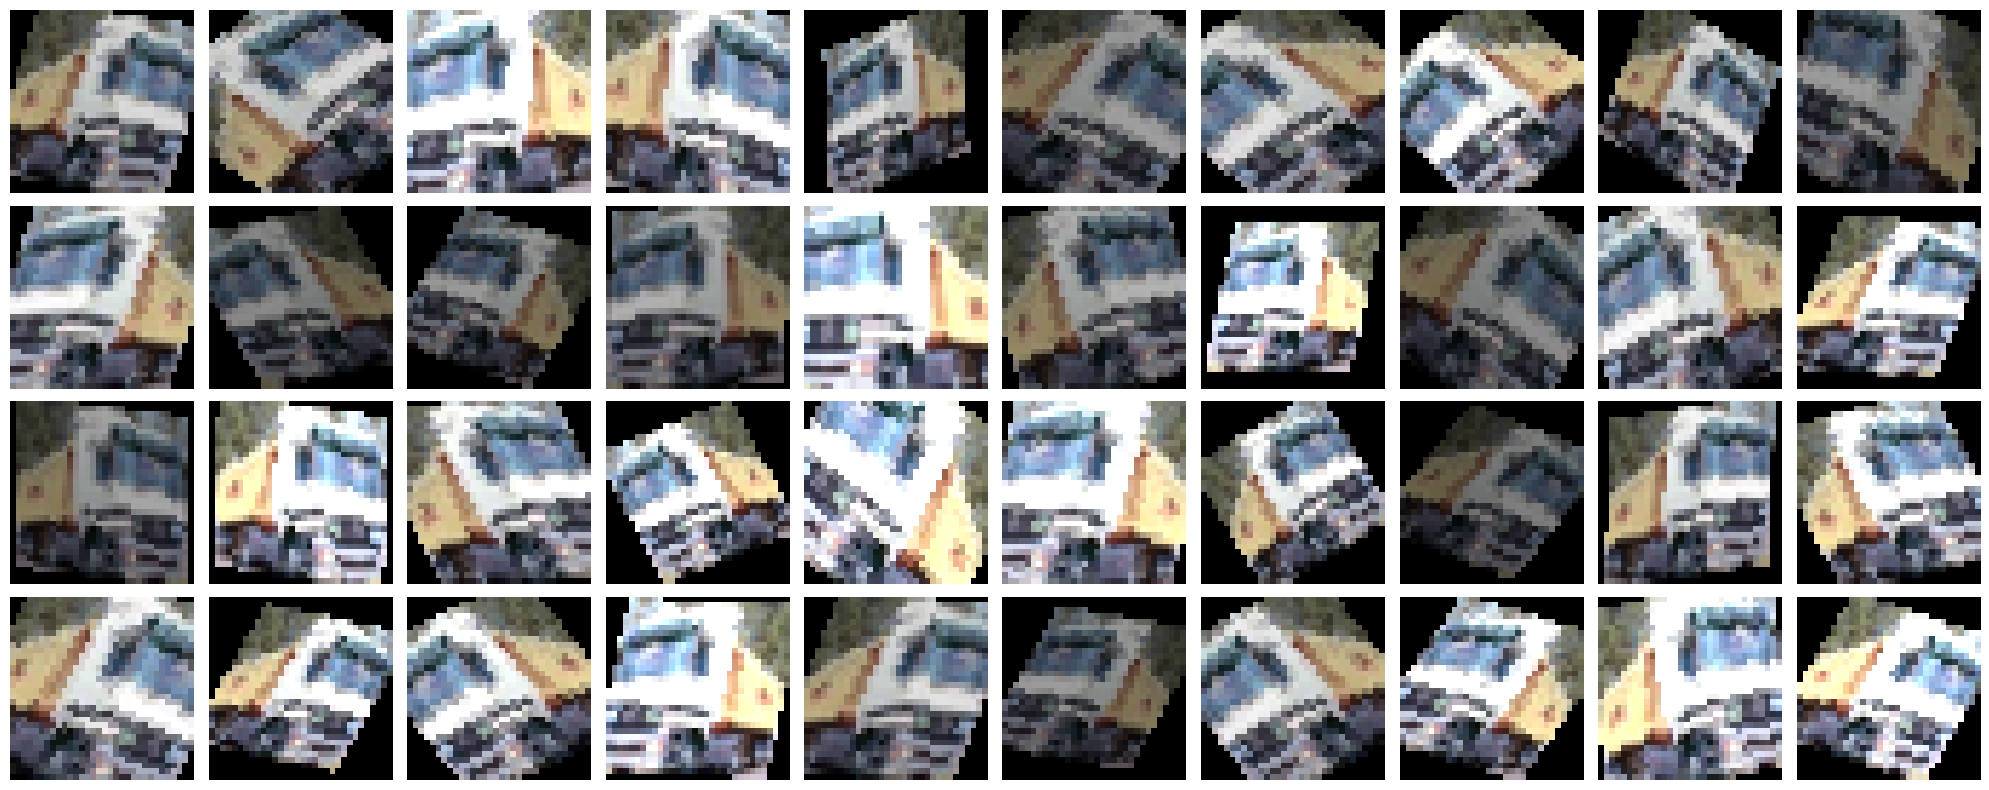

In [27]:
# Transformation on the Truck Images

num_images = 40
fig, axes = plt.subplots(4, 10, figsize=(20, 8))

for i, ax in enumerate(axes.flat):
    aug_tensor = augment(img_1)
    save_image(aug_tensor, os.path.join(save_folder2, f"image_{i+1:02d}.png"))
    ax.imshow(aug_tensor.permute(1, 2, 0).numpy())              #convertion to show using matplot lib (within the pytorch manal)
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(save_folder2, "grid.png"), dpi=100)
plt.show()

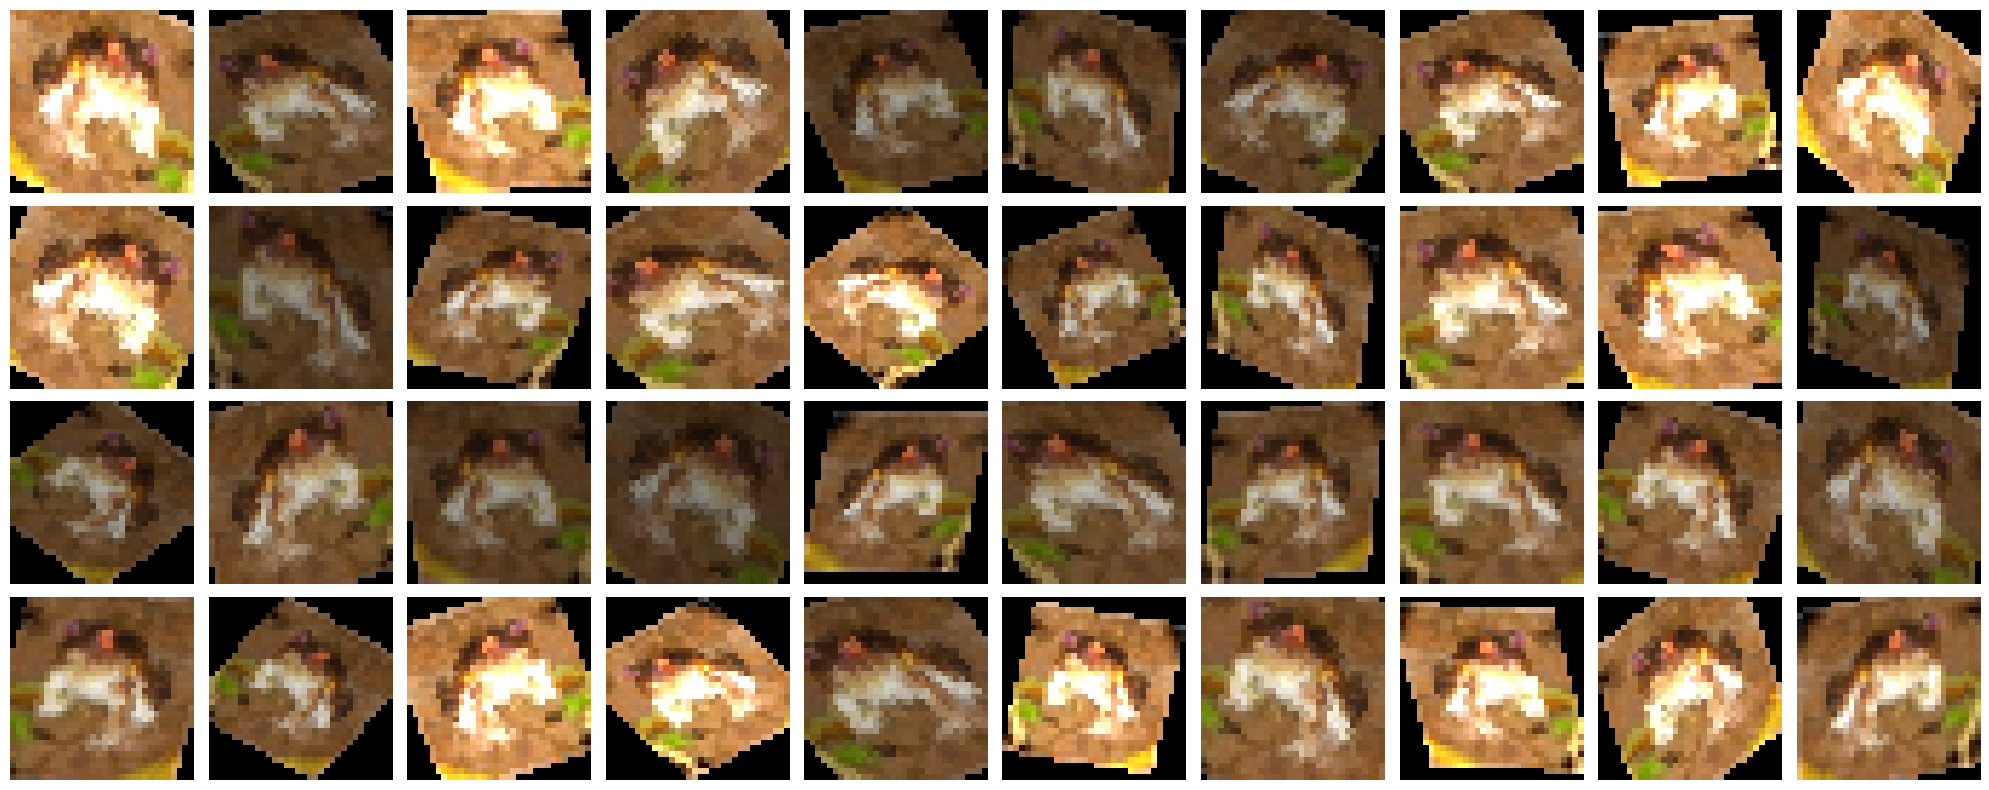

In [28]:
# Transformation on the Frog Images

num_images = 40
fig, axes = plt.subplots(4, 10, figsize=(20, 8))

for i, ax in enumerate(axes.flat):
    aug_tensor = augment(img_2)                                   # shape (3, 32, 32), values in [0, 1]
    save_image(aug_tensor, os.path.join(save_folder1, f"image_{i+1:02d}.png"))
    ax.imshow(aug_tensor.permute(1, 2, 0).numpy())              # CHW -> HWC for matplotlib
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(save_folder1, "grid.png"), dpi=100)
plt.show()

In [30]:
print(f"{num_images} augmented images of Frog saved in: {os.path.abspath(save_folder1)}")
print(f"{num_images} augmented images of Truck saved in: {os.path.abspath(save_folder2)}")


40 augmented images of Frog saved in: /content/Augmented Data frog
40 augmented images of Truck saved in: /content/Augmented Data Truck
